In [1]:
# import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import os 
import math
import sys
from pathlib import Path
import seaborn as sns

from src.data.process_data import *
from src.data.clean_data import *

# Add 'src' to the system path
sys.path.append(str(Path().resolve() / 'src'))

In [8]:
df_netflix = pd.read_csv('data/netflix_titles.csv')
df_netflix = df_netflix[df_netflix['type'] == 'Movie']

In [9]:
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [10]:
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], format='%B %d, %Y')

In [12]:
df_netflix['release_year'] = pd.to_datetime(df_netflix['release_year'], format='%Y')

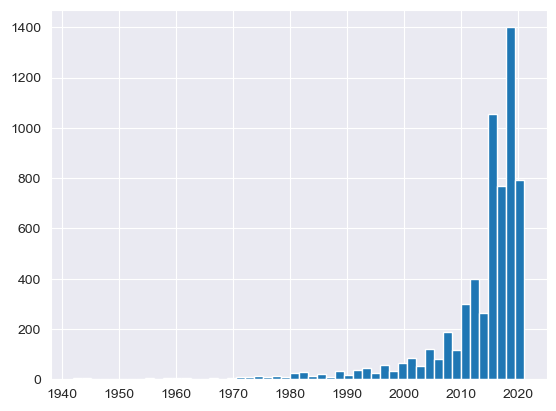

In [14]:
plt.hist(df_netflix['release_year'], bins=50)
plt.show()

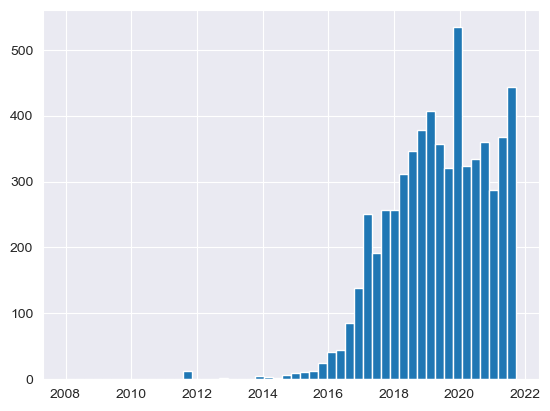

In [16]:
plt.hist(df_netflix['date_added'], bins=50)
plt.show()

In [18]:
df_netflix['time_diff'] = df_netflix['date_added'].dt.year - df_netflix['release_year'].dt.year

In [34]:
diff_per_year = df_netflix.groupby('release_year').agg(mean_diff=('time_diff', 'mean')).reset_index()
diff_per_year['release_year'] = diff_per_year['release_year'].dt.year #pd.to_datetime(diff_per_year['release_year'], format='%Y-%m-%d')

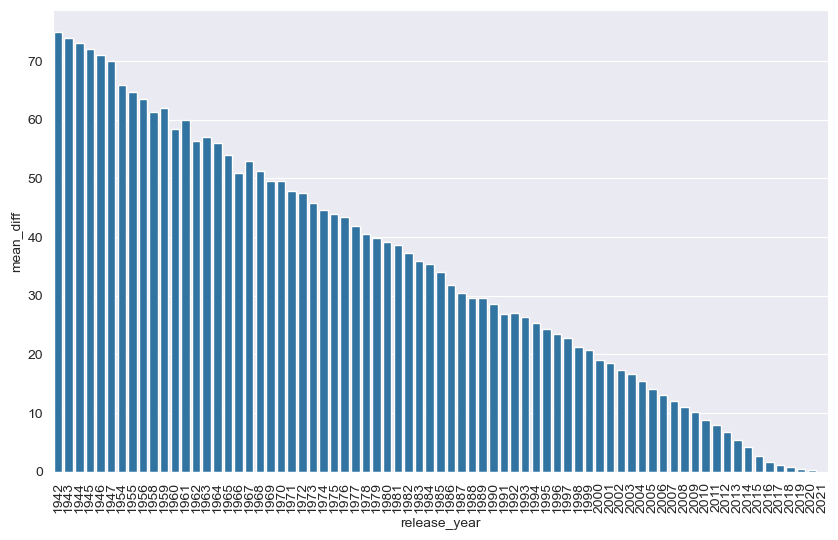

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(diff_per_year, x='release_year', y='mean_diff')
plt.xticks(rotation=90)
plt.show()

In [41]:
time_diff_2000s = diff_per_year[diff_per_year['release_year'] >= 2000]

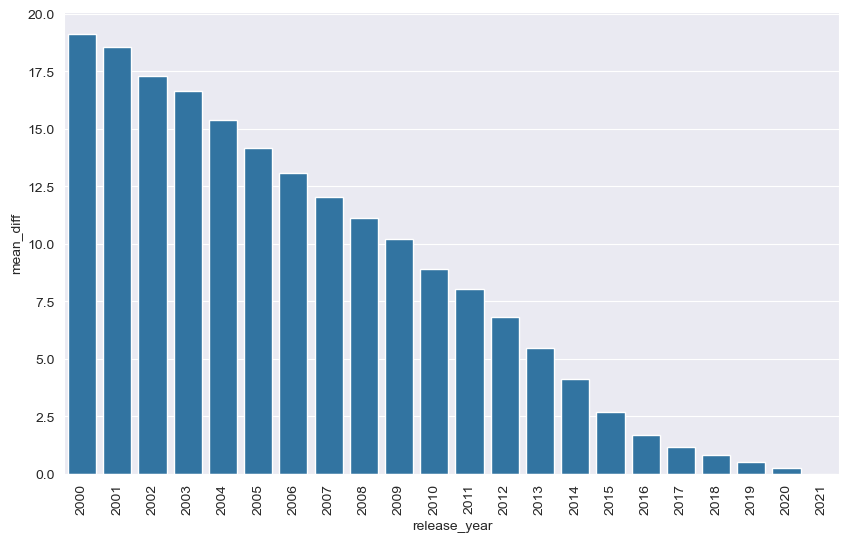

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(time_diff_2000s, x='release_year', y='mean_diff')
plt.xticks(rotation=90)
plt.show()